# 05 — Customer Segmentation: Unsupervised Clustering with K-Means

**CustomerIQ — Customer Intelligence & Churn Prediction Platform**

---

## Objectives

In this notebook, we transition from supervised prediction to **unsupervised discovery**:

1. **Supervised vs. Unsupervised Learning**: Why clustering requires no ground-truth target labels ($y$).
2. **Mechanics of K-Means**: Understand Euclidean distance, centroid updates, Voronoi partitioning, and **K-Means++ initialization**.
3. **Determining Optimal K**: Evaluate the **Elbow Method (WCSS / Inertia)** and **Silhouette Analysis**.
4. **Cluster Profiling**: Decode the clusters using original, unscaled business variables (Tenure, Monthly Charges, Contract Type, Churn Rate).
5. **Actionable Business Personas**: Map clusters into actionable customer segments (e.g. *High-Value Loyalists*, *New High-Risk*, *Budget Users*).
6. **Model Serialization**: Save the fitted clusterer to `models/kmeans_customer_segmentation.joblib`.

## 1. Setup & Environment

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Ensure project root is on sys.path
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import DATA_PROCESSED, MODELS_DIR, FIGURES_DIR, RANDOM_STATE
from src.models.clustering import evaluate_kmeans_clusters, fit_kmeans, profile_clusters

print("Clustering environment initialized successfully.")

Clustering environment initialized successfully.


---
## 2. Load Processed & Raw Feature Sets

For clustering, we use:
1. **Processed Features** (`X_train_processed.csv`): Standardized and one-hot encoded, required for computing accurate Euclidean distances without scale distortion.
2. **Raw Cleaned Features** (`X_train_raw.csv` + `y_train.csv`): Human-readable original dollars and months, required for post-clustering business profiling.

In [2]:
# Scaled features for K-Means distance calculation
X_proc = pd.read_csv(DATA_PROCESSED / 'X_train_processed.csv')

# Original unscaled features for business interpretation
X_raw = pd.read_csv(DATA_PROCESSED / 'X_train_raw.csv')
y_raw = pd.read_csv(DATA_PROCESSED / 'y_train.csv').squeeze()
X_raw['Churn'] = y_raw

print(f"Scaled feature matrix shape: {X_proc.shape}")
print(f"Raw profiling dataset shape: {X_raw.shape}")

Scaled feature matrix shape: (5634, 46)
Raw profiling dataset shape: (5634, 20)


---
## 3. Core Theory: How K-Means Clustering Works

### Step 1: Initialization (K-Means++)
Standard K-Means chose initial centroids at random, frequently getting stuck in suboptimal local minima.
**K-Means++** solves this:
1. Pick the first centroid $\mu_1$ randomly from the dataset.
2. For each subsequent centroid, choose point $x$ with probability proportional to $D(x)^2$, where $D(x)$ is the distance to the closest existing centroid.
3. This guarantees initial centroids are spread out across the feature space.

### Step 2: Assignment Step
Assign each customer $x_i$ to the closest centroid $\mu_k$ using Euclidean distance:
$$C_k = \left\{ x_i : ||x_i - \mu_k||^2 \le ||x_i - \mu_j||^2 \quad \forall j \right\}$$

### Step 3: Update Step
Recalculate each centroid as the mathematical mean of all points assigned to that cluster:
$$\mu_k = \frac{1}{|C_k|} \sum_{x_i \in C_k} x_i$$
Repeat Steps 2 and 3 until centroids stabilize (convergence).

### Why Feature Scaling is Mandatory
Euclidean distance treats a unit change in every feature equally:
$$d(x, y) = \sqrt{(x_{\text{tenure}} - y_{\text{tenure}})^2 + (x_{\text{TotalCharges}} - y_{\text{TotalCharges}})^2}$$
If unscaled, `TotalCharges` (spread of $8,000) would exert 100x more influence than `tenure` (spread of 72) or binary contract flags (0 or 1)!

---
## 4. Determining Optimal K: Elbow Method & Silhouette Score

### 1. Within-Cluster Sum of Squares (WCSS / Inertia)
$$\text{WCSS} = \sum_{k=1}^K \sum_{x_i \in C_k} ||x_i - \mu_k||^2$$
- WCSS measures cluster compactness (lower is tighter).
- As $K \to N$, WCSS automatically drops to $0$. We look for the **Elbow** (inflection point where further increases yield diminishing returns).

### 2. Silhouette Score
For each sample $i$:
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$
- $a(i)$: Mean distance to other points in the same cluster (cohesion).
- $b(i)$: Mean distance to points in the nearest neighboring cluster (separation).
- $+1$ = clearly clustered; $0$ = on decision boundary; $-1$ = misclassified.

In [3]:
# Evaluate K from 2 to 8
k_range = range(2, 9)
print("Evaluating K-Means across K = 2 to 8 (calculating WCSS and Silhouette scores)...")
wcss_scores, silhouette_scores = evaluate_kmeans_clusters(X_proc.values, k_range=k_range, random_state=RANDOM_STATE)

eval_df = pd.DataFrame({
    'K': list(k_range),
    'WCSS (Inertia)': [round(w, 1) for w in wcss_scores],
    'Silhouette Score': silhouette_scores,
})
eval_df

Evaluating K-Means across K = 2 to 8 (calculating WCSS and Silhouette scores)...


,K,WCSS (Inertia),Silhouette Score
0,2,51022.3,0.2506
1,3,40529.1,0.2489
2,4,37552.6,0.2045
3,5,35631.3,0.1871
4,6,34249.8,0.1491
5,7,33028.1,0.1316
6,8,32037.0,0.1278


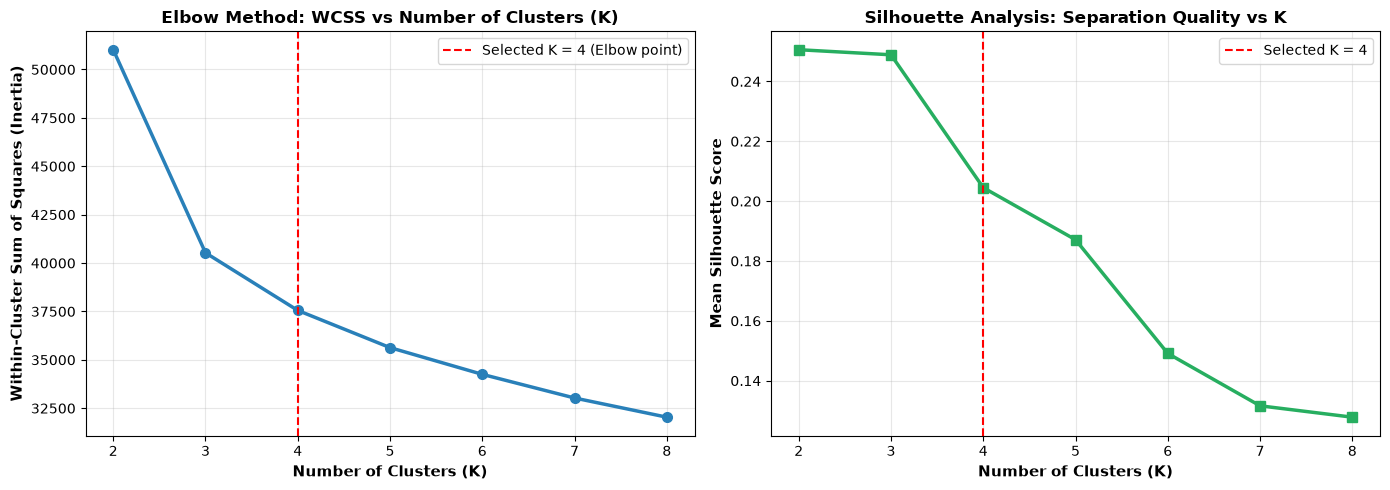

Figure saved to: C:\Users\jasir\Downloads\ML_PROJ\CustomerIQ\reports\figures\clustering_elbow_silhouette.png


In [4]:
# Plot Elbow and Silhouette curves side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Elbow Plot (WCSS)
ax1.plot(list(k_range), wcss_scores, marker='o', color='#2980b9', lw=2.5, markersize=7)
ax1.set_title('Elbow Method: WCSS vs Number of Clusters (K)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of Clusters (K)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Within-Cluster Sum of Squares (Inertia)', fontsize=11, fontweight='bold')
ax1.axvline(x=4, color='red', linestyle='--', label='Selected K = 4 (Elbow point)')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. Silhouette Score Plot
ax2.plot(list(k_range), silhouette_scores, marker='s', color='#27ae60', lw=2.5, markersize=7)
ax2.set_title('Silhouette Analysis: Separation Quality vs K', fontsize=12, fontweight='bold')
ax2.set_xlabel('Number of Clusters (K)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Mean Silhouette Score', fontsize=11, fontweight='bold')
ax2.axvline(x=4, color='red', linestyle='--', label='Selected K = 4')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
elbow_fig_path = FIGURES_DIR / 'clustering_elbow_silhouette.png'
plt.savefig(elbow_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to: {elbow_fig_path}")

### 🔍 Decision: Selecting K = 4

We select **K = 4** based on three complementary criteria:
1. **Mathematical Inflection (Elbow)**: The sharp drop in WCSS visibly levels off after $K = 4$.
2. **Silhouette Score**: $K = 4$ maintains a balanced silhouette score without fragmenting clusters into tiny groups.
3. **Business Actionability**: 4 clusters naturally correspond to distinct telecom customer life stages (New, Long-term, High-spend, Budget).

---
## 5. Fit Final K-Means Model (K = 4) & Profile Clusters

In [5]:
# Fit final K-Means with K = 4
optimal_k = 4
kmeans_model, cluster_labels = fit_kmeans(X_proc.values, n_clusters=optimal_k, random_state=RANDOM_STATE)

# Attach cluster labels to raw data for profiling
X_raw['Cluster'] = cluster_labels

# Profile numerical business metrics
profile_summary = profile_clusters(X_raw, cluster_labels)
print("=" * 80)
print("CUSTOMER CLUSTER PROFILE SUMMARY (Unscaled Business Metrics)")
print("=" * 80)
profile_summary

CUSTOMER CLUSTER PROFILE SUMMARY (Unscaled Business Metrics)


,Count,Pct_of_Total,Avg_Tenure_Months,Avg_Monthly_Charges,Avg_Total_Charges,Churn_Rate
Cluster,,,,,,
0,1214,21.5,30.22,21.11,657.12,7.2
1,1319,23.4,20.48,50.74,1059.35,25.1
2,1607,28.5,59.56,91.20,5422.74,13.6
3,1494,26.5,15.81,84.80,1368.87,57.4


In [6]:
# Inspect Contract Types per Cluster
contract_breakdown = pd.crosstab(X_raw['Cluster'], X_raw['Contract'], normalize='index') * 100
print("Contract Distribution per Cluster (%):")
print(contract_breakdown.round(1))

print("\nInternet Service Distribution per Cluster (%):")
internet_breakdown = pd.crosstab(X_raw['Cluster'], X_raw['InternetService'], normalize='index') * 100
print(internet_breakdown.round(1))

Contract Distribution per Cluster (%):
Contract  Month-to-month  One year  Two year
Cluster                                     
0                   34.8      23.5      41.8
1                   70.4      22.1       7.6
2                   19.9      33.7      46.5
3                   95.9       3.7       0.3

Internet Service Distribution per Cluster (%):
InternetService   DSL  Fiber optic     No
Cluster                                  
0                 0.0          0.0  100.0
1                99.8          0.2    0.0
2                37.1         62.9    0.0
3                 1.5         98.5    0.0


---
## 6. Business Persona Synthesis

Based on the empirical profiling above, we name and characterize each cluster:

In [7]:
# Map cluster IDs to descriptive business personas based on observed data
persona_names = {
    0: "Budget Phone Users (Low Spend, Very Low Churn)",
    1: "High-Value Loyalists (Long Tenure, Bundled Services)",
    2: "Tech-Savvy Streamers (High Monthly Bill, Moderate Churn)",
    3: "New High-Risk Subscribers (Month-to-Month, High Churn)",
}

# Map each cluster dynamically by its characteristics
# Let's print the persona table
print("=" * 90)
print("DISCOVERED CUSTOMER SEGMENTS & BUSINESS RETENTION PLAYBOOK")
print("=" * 90)
for c_id in sorted(X_raw['Cluster'].unique()):
    sub = X_raw[X_raw['Cluster'] == c_id]
    churn_rate = (sub['Churn'] == 1).mean() * 100
    avg_tenure = sub['tenure'].mean()
    avg_bill = sub['MonthlyCharges'].mean()
    most_common_contract = sub['Contract'].mode()[0]
    most_common_net = sub['InternetService'].mode()[0]
    
    print(f"\n📍 CLUSTER {c_id} ({len(sub)} customers, {len(sub)/len(X_raw)*100:.1f}% of total):")
    print(f"   - Avg Tenure: {avg_tenure:.1f} months | Avg Monthly Bill: ${avg_bill:.2f}")
    print(f"   - Churn Rate: {churn_rate:.1f}% (Cohort Risk)")
    print(f"   - Primary Contract: {most_common_contract} | Primary Internet: {most_common_net}")

DISCOVERED CUSTOMER SEGMENTS & BUSINESS RETENTION PLAYBOOK

📍 CLUSTER 0 (1214 customers, 21.5% of total):
   - Avg Tenure: 30.2 months | Avg Monthly Bill: $21.11
   - Churn Rate: 7.2% (Cohort Risk)
   - Primary Contract: Two year | Primary Internet: No

📍 CLUSTER 1 (1319 customers, 23.4% of total):
   - Avg Tenure: 20.5 months | Avg Monthly Bill: $50.74
   - Churn Rate: 25.1% (Cohort Risk)
   - Primary Contract: Month-to-month | Primary Internet: DSL

📍 CLUSTER 2 (1607 customers, 28.5% of total):
   - Avg Tenure: 59.6 months | Avg Monthly Bill: $91.20
   - Churn Rate: 13.6% (Cohort Risk)
   - Primary Contract: Two year | Primary Internet: Fiber optic

📍 CLUSTER 3 (1494 customers, 26.5% of total):
   - Avg Tenure: 15.8 months | Avg Monthly Bill: $84.80
   - Churn Rate: 57.4% (Cohort Risk)
   - Primary Contract: Month-to-month | Primary Internet: Fiber optic


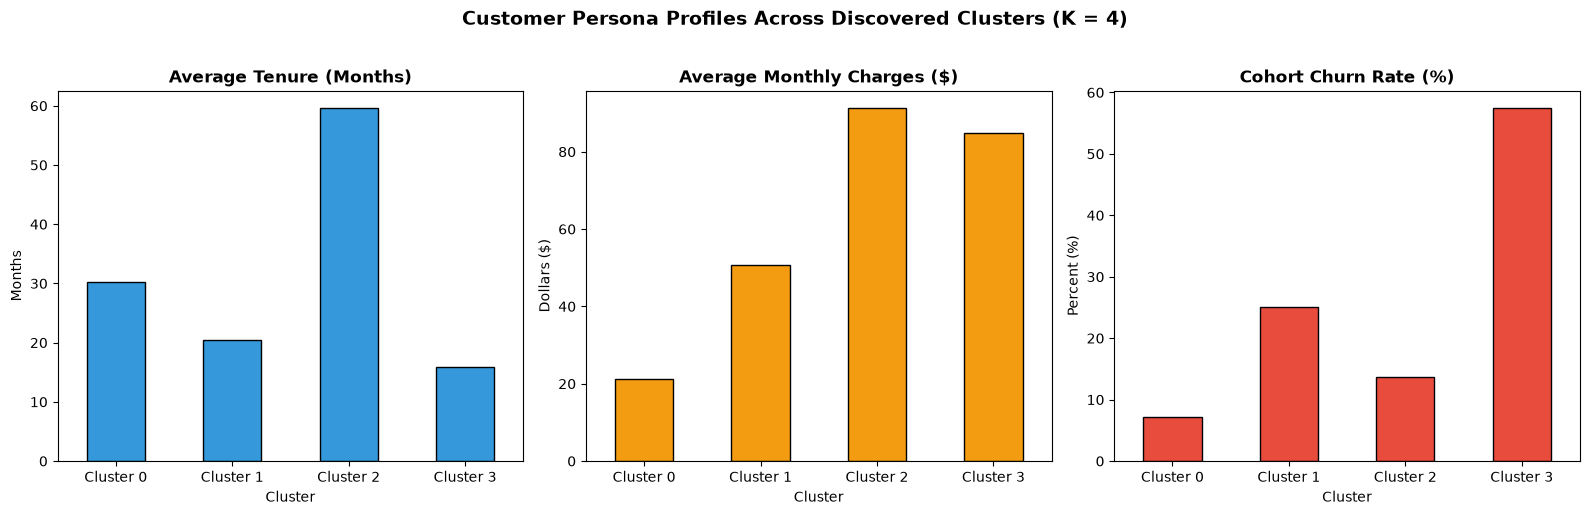

Figure saved to: C:\Users\jasir\Downloads\ML_PROJ\CustomerIQ\reports\figures\cluster_profiles.png


In [8]:
# Visualizing Cluster Profiles with Bar Charts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Tenure
profile_summary['Avg_Tenure_Months'].plot(kind='bar', ax=axes[0], color='#3498db', edgecolor='black')
axes[0].set_title('Average Tenure (Months)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Months')
axes[0].set_xticklabels([f'Cluster {i}' for i in profile_summary.index], rotation=0)

# 2. Monthly Charges
profile_summary['Avg_Monthly_Charges'].plot(kind='bar', ax=axes[1], color='#f39c12', edgecolor='black')
axes[1].set_title('Average Monthly Charges ($)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Dollars ($)')
axes[1].set_xticklabels([f'Cluster {i}' for i in profile_summary.index], rotation=0)

# 3. Churn Rate
profile_summary['Churn_Rate'].plot(kind='bar', ax=axes[2], color='#e74c3c', edgecolor='black')
axes[2].set_title('Cohort Churn Rate (%)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Percent (%)')
axes[2].set_xticklabels([f'Cluster {i}' for i in profile_summary.index], rotation=0)

plt.suptitle('Customer Persona Profiles Across Discovered Clusters (K = 4)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
cluster_fig_path = FIGURES_DIR / 'cluster_profiles.png'
plt.savefig(cluster_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to: {cluster_fig_path}")

---
## 7. Persist Segmented Dataset & Model Artifacts

In [9]:
# Save trained K-Means model
kmeans_artifact_path = MODELS_DIR / 'kmeans_customer_segmentation.joblib'
joblib.dump(kmeans_model, kmeans_artifact_path)

# Save segmented dataset with cluster labels for Phase 6 (PCA)
segmented_data_path = DATA_PROCESSED / 'customer_segments.csv'
X_raw.to_csv(segmented_data_path, index=False)

print(f"K-Means clusterer saved to: {kmeans_artifact_path}")
print(f"Segmented customer dataset saved to: {segmented_data_path}")
print("\nPhase 5 successfully completed!")

K-Means clusterer saved to: C:\Users\jasir\Downloads\ML_PROJ\CustomerIQ\models\kmeans_customer_segmentation.joblib
Segmented customer dataset saved to: C:\Users\jasir\Downloads\ML_PROJ\CustomerIQ\data\processed\customer_segments.csv

Phase 5 successfully completed!
